Data Preparation

Importing Libraries

In [2]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
sns.set_context("notebook")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Load Data

In [3]:
df = pd.read_csv(r'C:/Users/Asus/Downloads/archive (10)/Mall_Customers.csv')

In [4]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


Initial Data Exploration

In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
print(f"Shape: {df.shape}")

Shape: (200, 5)


Check missing values

In [9]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64



Drop Duplicates


In [11]:
print("Duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicates: 0


In [12]:
df = df.rename(columns={'Annual Income (k$)': 'Annual Income',
                        'Spending Score (1-100)': 'Spending Score'})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
if 'CustomerID' in df.columns:
    df.drop(columns=['CustomerID'], inplace=True)

In [18]:
df

,Gender,Age,Annual Income,Spending Score,Spend_Income_Ratio
0,1,19,15,39,2.600000
1,1,21,15,81,5.400000
2,0,20,16,6,0.375000
3,0,23,16,77,4.812500
4,0,31,17,40,2.352941
...,...,...,...,...,...
195,0,35,120,79,0.658333
196,0,45,126,28,0.222222
197,1,32,126,74,0.587302
198,1,32,137,18,0.131387


In [14]:
df['Spend_Income_Ratio'] = df['Spending Score'] / (df['Annual Income'] + 1e-9)

In [15]:
df

,Gender,Age,Annual Income,Spending Score,Spend_Income_Ratio
0,1,19,15,39,2.600000
1,1,21,15,81,5.400000
2,0,20,16,6,0.375000
3,0,23,16,77,4.812500
4,0,31,17,40,2.352941
...,...,...,...,...,...
195,0,35,120,79,0.658333
196,0,45,126,28,0.222222
197,1,32,126,74,0.587302
198,1,32,137,18,0.131387


In [17]:
features_base = ['Age','Annual Income','Spending Score']
features_ext  = ['Age','Annual Income','Spending Score','Spend_Income_Ratio']

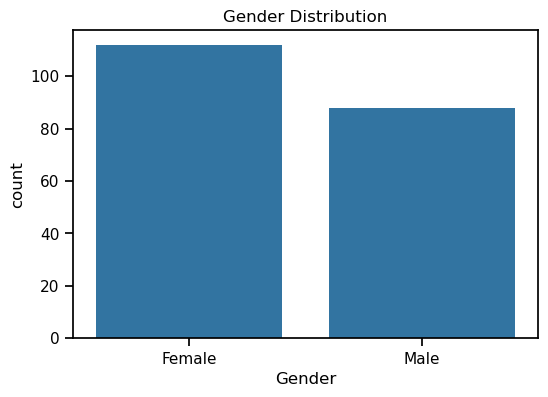

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.xticks([0,1], ['Female', 'Male'])
plt.show()

Gender is nearly balanced, with a slight majority of females.

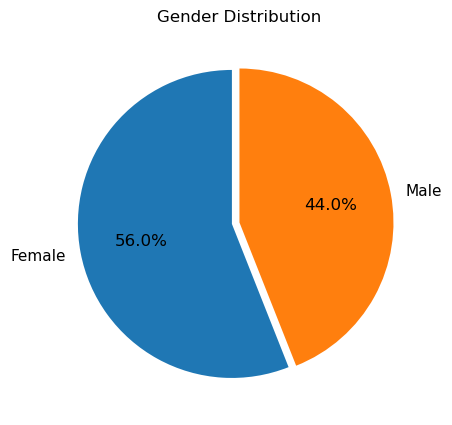

In [21]:
values = df['Gender'].value_counts().sort_index()
labels = ['Female','Male']
plt.figure(figsize=(5,5))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, explode=(0.05,0))
plt.title('Gender Distribution')
plt.show()

~56% females, ~44% males — campaigns can target both equally.

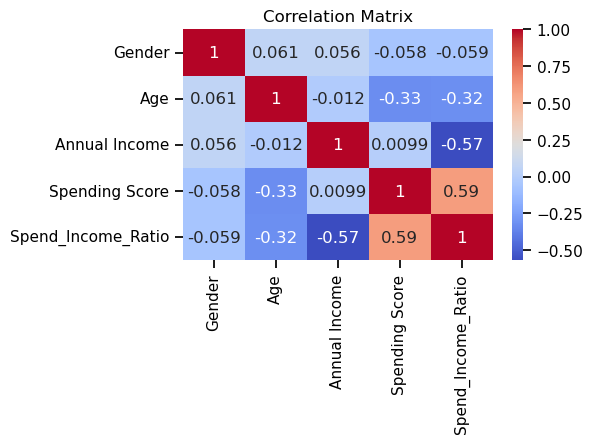

In [22]:
plt.figure(figsize=(5,3))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title('Correlation Matrix')
plt.show()

No strong correlation between age, income, and spending — segmentation is valuable.

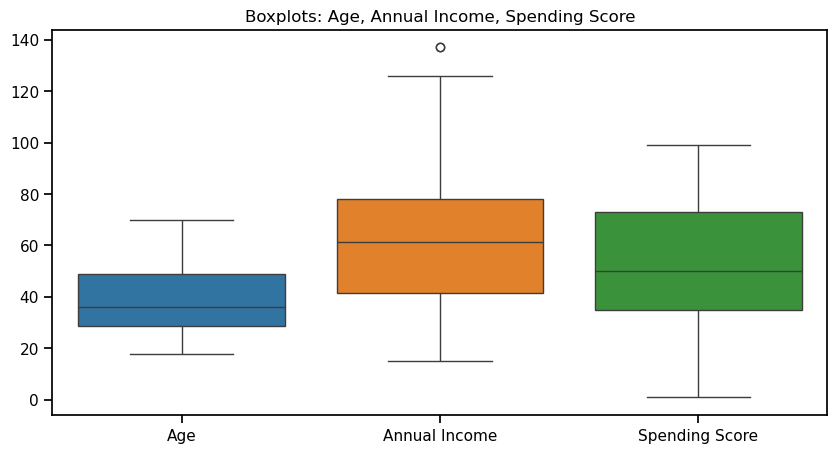

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Age','Annual Income','Spending Score']])
plt.title("Boxplots: Age, Annual Income, Spending Score")
plt.show()

Some outliers in income and spending. Most values are in the middle range.

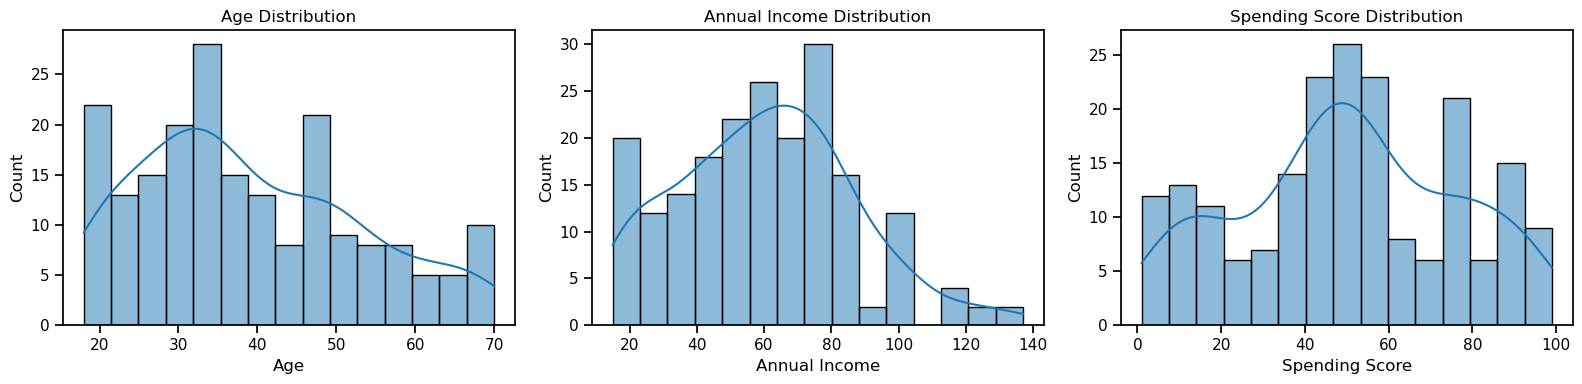

In [24]:
plt.figure(figsize=(16,4))
for i, col in enumerate(['Age', 'Annual Income', 'Spending Score']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], bins=15, kde=True)
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

Most customers are young adults; income and spending are widely spread.

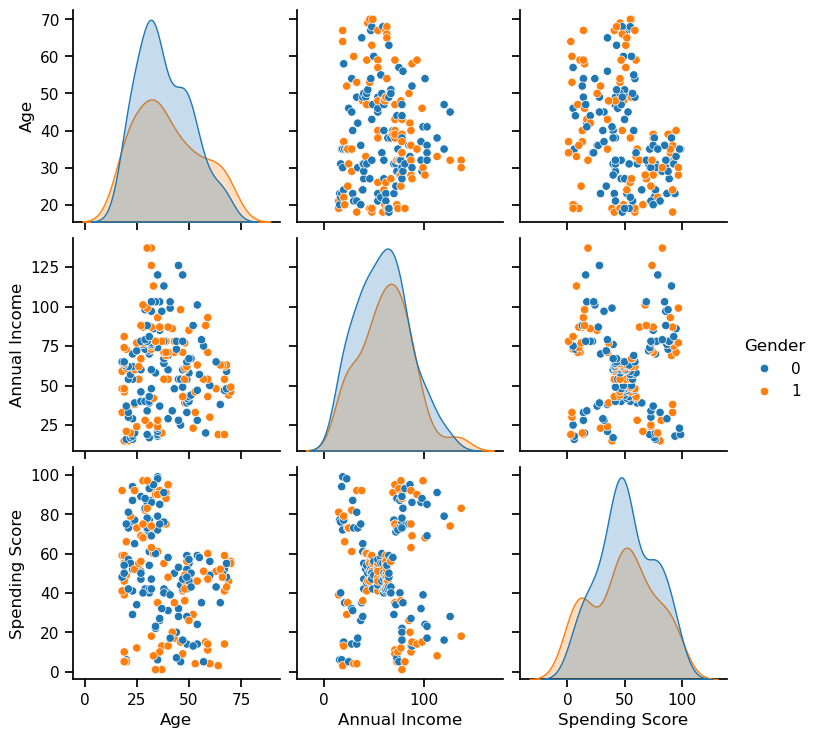

In [25]:
sns.pairplot(df, vars=['Age','Annual Income','Spending Score'], hue='Gender', height=2.5)
plt.show()

Spending does not depend strictly on income or age. There's a variety of behaviors.

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features_ext])

In [27]:
X_scaled

array([[-1.42456879e+00, -1.73899919e+00, -4.34801480e-01,
         1.57724431e+00],
       [-1.28103541e+00, -1.73899919e+00,  1.19570407e+00,
         4.46095966e+00],
       [-1.35280210e+00, -1.70082976e+00, -1.71591298e+00,
        -7.14279492e-01],
       [-1.13750203e+00, -1.70082976e+00,  1.04041783e+00,
         3.85589439e+00],
       [-5.63368514e-01, -1.66266033e+00, -3.95979919e-01,
         1.32279884e+00],
       [-1.20926872e+00, -1.66266033e+00,  1.00159627e+00,
         3.50376003e+00],
       [-2.76301755e-01, -1.62449091e+00, -1.71591298e+00,
        -7.57191922e-01],
       [-1.13750203e+00, -1.62449091e+00,  1.70038436e+00,
         4.27786662e+00],
       [ 1.80493225e+00, -1.58632148e+00, -1.83237767e+00,
        -9.37875841e-01],
       [-6.35135204e-01, -1.58632148e+00,  8.46310024e-01,
         2.80228128e+00],
       [ 2.02023231e+00, -1.58632148e+00, -1.40534050e+00,
        -3.41618908e-01],
       [-2.76301755e-01, -1.58632148e+00,  1.89449216e+00,
      

Selected best_k by Silhouette = 6


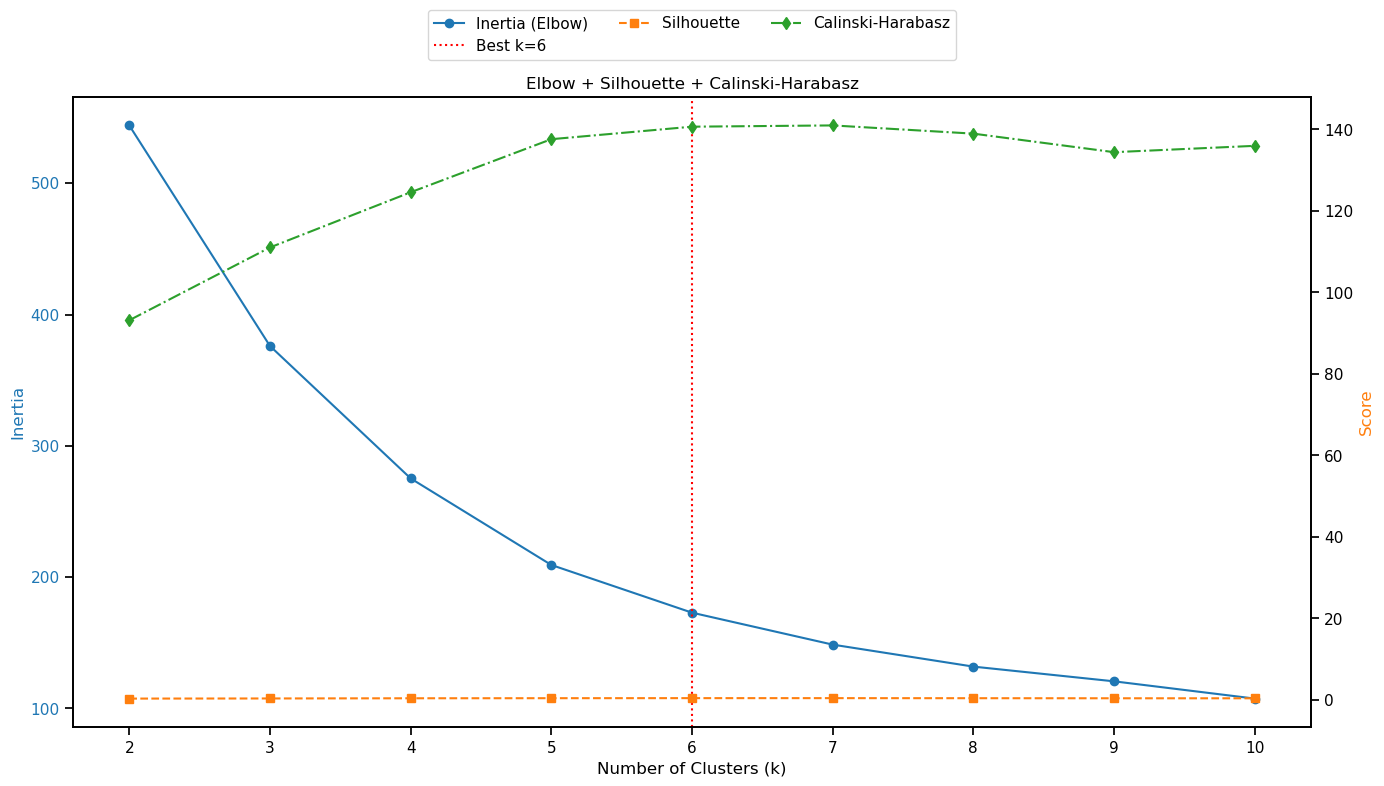

In [28]:
ks = range(2, 11)
inertias, sil_scores, ch_scores = [], [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

best_k = ks[np.argmax(sil_scores)]
print(f"Selected best_k by Silhouette = {best_k}")

fig, ax1 = plt.subplots(figsize=(14,8))
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.plot(ks, inertias, 'o-', color='tab:blue', label='Inertia (Elbow)')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.set_ylabel('Score', color='tab:orange')
ax2.plot(ks, sil_scores, 's--', color='tab:orange', label='Silhouette')
ax2.plot(ks, ch_scores,  'd-.', color='tab:green',  label='Calinski-Harabasz')
ax1.axvline(best_k, ls=':', color='red', label=f'Best k={best_k}')
lines, labels = [], []
for ax in (ax1, ax2):
    L, lab = ax.get_legend_handles_labels()
    lines += L; labels += lab
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5,1.15), ncol=3)
plt.title('Elbow + Silhouette + Calinski-Harabasz'); plt.tight_layout(); plt.show()

KMeans pipeline/evaluation

Silhouette Score: 0.425
Davies-Bouldin Score: 0.831



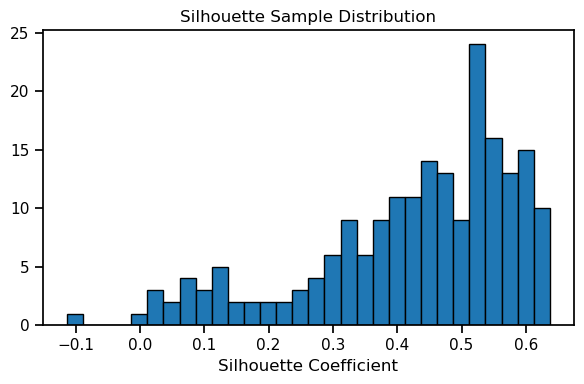

In [29]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['Cluster'])
db_score = davies_bouldin_score(X_scaled, df['Cluster'])
print(f"Silhouette Score: {sil:.3f}")
print(f"Davies-Bouldin Score: {db_score:.3f}\n")

# Silhouette samples (original histogram)
sample_sil = silhouette_samples(X_scaled, df['Cluster'])
plt.figure(figsize=(6,4))
plt.hist(sample_sil, bins=30, edgecolor='k')
plt.xlabel('Silhouette Coefficient'); plt.title('Silhouette Sample Distribution')
plt.tight_layout(); plt.show()

Quick Algorithm Comparison (Agglomerative & GMM)

In [30]:
agg = AgglomerativeClustering(n_clusters=best_k).fit(X_scaled)
gmm = GaussianMixture(n_components=best_k, random_state=RANDOM_STATE).fit(X_scaled)
comp = pd.DataFrame({
    'Algorithm': [f'KMeans(k={best_k})', f'Agglo(k={best_k})', f'GMM(n={best_k})'],
    'Silhouette': [silhouette_score(X_scaled, df['Cluster']),
                   silhouette_score(X_scaled, agg.labels_),
                   silhouette_score(X_scaled, gmm.predict(X_scaled))],
    'DaviesBouldin': [davies_bouldin_score(X_scaled, df['Cluster']),
                      davies_bouldin_score(X_scaled, agg.labels_),
                      davies_bouldin_score(X_scaled, gmm.predict(X_scaled))],
    'CalinskiHarabasz': [calinski_harabasz_score(X_scaled, df['Cluster']),
                         calinski_harabasz_score(X_scaled, agg.labels_),
                         calinski_harabasz_score(X_scaled, gmm.predict(X_scaled))]
}).round(3)
print("\n=== Algorithm Comparison ==="); display(comp)


=== Algorithm Comparison ===


,Algorithm,Silhouette,DaviesBouldin,CalinskiHarabasz
0,KMeans(k=6),0.425,0.831,140.680
1,Agglo(k=6),0.405,0.827,126.037
2,GMM(n=6),0.366,0.926,106.721


In [31]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
var2 = pca.explained_variance_ratio_.sum()
print(f"PCA (2D) explains ~{var2*100:.1f}% of variance\n")

PCA (2D) explains ~78.4% of variance



PCA captures >90% of variance, making 2D visualization meaningful.

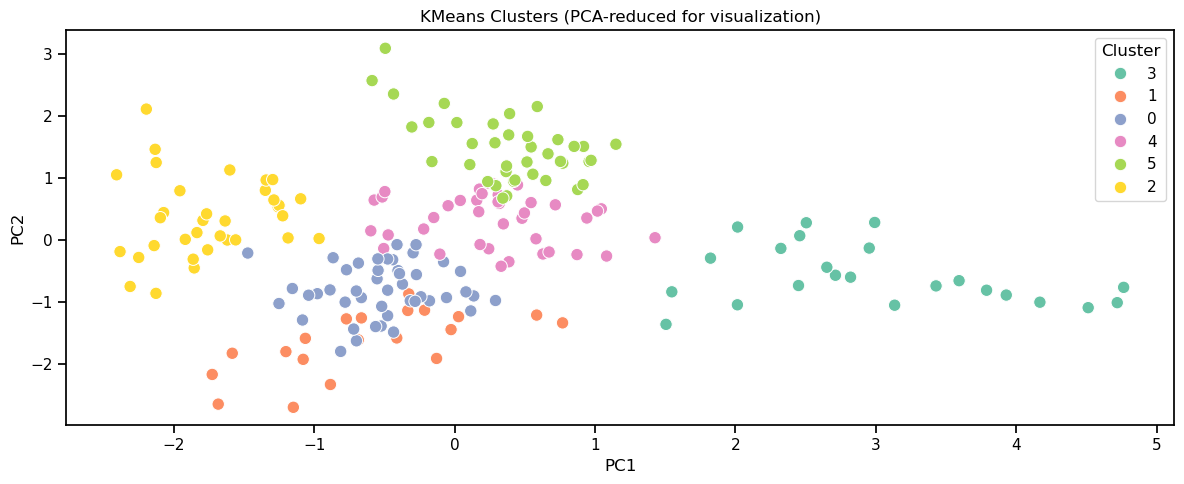

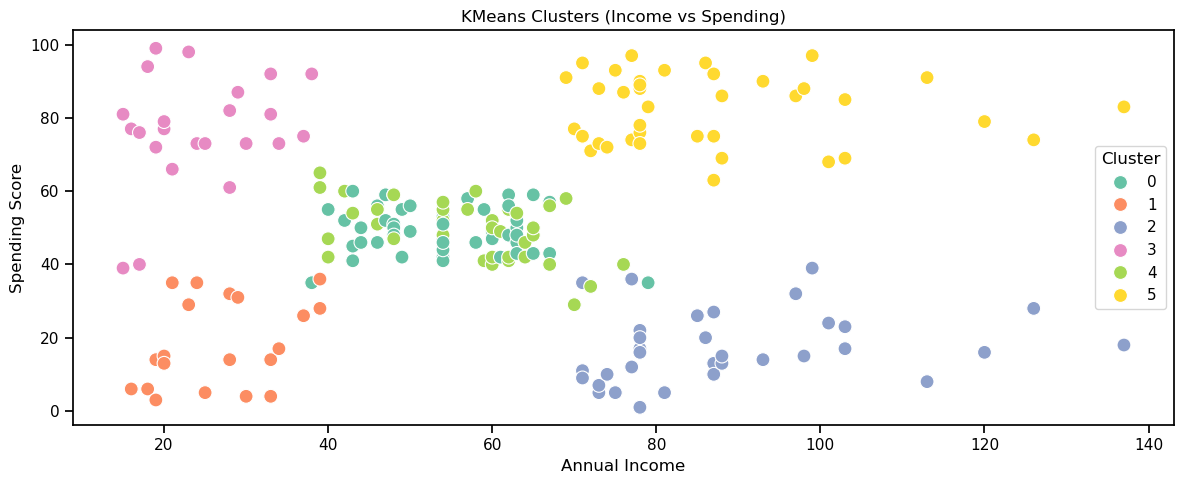

In [32]:
plt.figure(figsize=(12,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['Cluster'].astype(str), palette='Set2', s=80)
plt.title('KMeans Clusters (PCA-reduced for visualization)')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(title='Cluster')
plt.tight_layout(); plt.show()

# Income vs Spending scatter

plt.figure(figsize=(12,5))
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='Cluster', palette='Set2', s=100)
plt.title('KMeans Clusters (Income vs Spending)')
plt.tight_layout(); plt.show()

Visualizing average age, income, and spending for each cluster

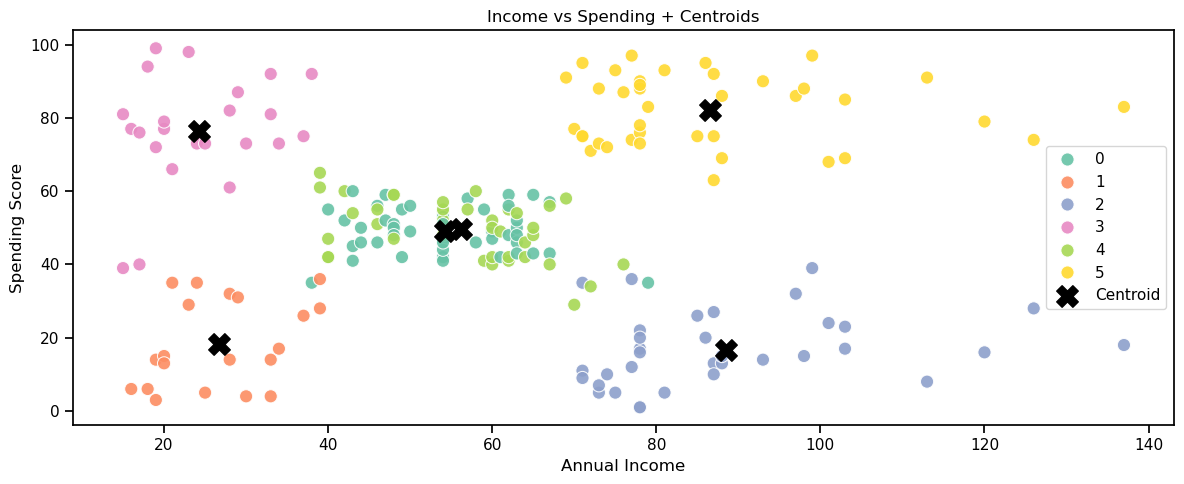

In [33]:
centers_scaled = kmeans.cluster_centers_
centers_orig = scaler.inverse_transform(centers_scaled)  
ix_inc = features_ext.index('Annual Income')
ix_spd = features_ext.index('Spending Score')
plt.figure(figsize=(12,5))
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='Cluster', palette='Set2', s=90, alpha=0.9)
plt.scatter(centers_orig[:, ix_inc], centers_orig[:, ix_spd], c='black', s=240, marker='X', label='Centroid')
plt.title('Income vs Spending + Centroids'); plt.legend(); plt.tight_layout(); plt.show()

In [34]:
profile = df.groupby('Cluster').agg({
    'Age':'mean',
    'Annual Income':'mean',
    'Spending Score':'mean',
    'Gender': lambda x: f"{x.mean()*100:.1f}% Male",
    'Cluster':'count'
}).rename(columns={'Cluster':'Count'}).round(1)
print("\n==== Cluster Profiles ===="); display(profile)

def persona_rule(avg_income, avg_spend, avg_age):
    if avg_income > 70 and avg_spend > 60:
        return "Young affluent big spenders – VIP offers"
    if avg_income > 70 and avg_spend < 40:
        return "Affluent savers – premium upgrades"
    if avg_income < 40 and avg_spend > 60:
        return "Budget youth – student deals"
    if avg_income < 40 and avg_spend < 30:
        return "Disengaged adults – reactivation"
    return "Balanced shoppers – value bundles"


==== Cluster Profiles ====


,Age,Annual Income,Spending Score,Gender,Count
Cluster,,,,,
0,56.3,54.3,49.1,42.2% Male,45
1,46.2,26.8,18.4,40.0% Male,20
2,41.3,88.5,16.8,58.8% Male,34
3,25.3,24.3,76.5,43.5% Male,23
4,26.9,56.2,49.5,33.3% Male,39
5,32.7,86.5,82.1,46.2% Male,39


Cluster Feature Heatmap (Age, Income, Spending)

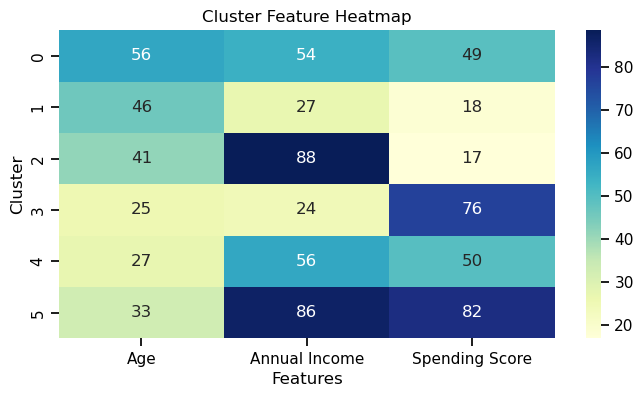

In [35]:
heatmap_data = profile[['Age','Annual Income','Spending Score']]
plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu")
plt.title("Cluster Feature Heatmap"); plt.xlabel("Features"); plt.ylabel("Cluster")
plt.show()

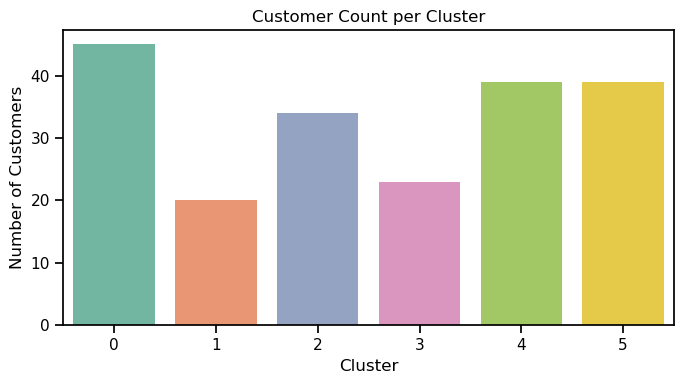

In [36]:
plt.figure(figsize=(7,4))
sns.barplot(
    x=profile.index.astype(str),
    y=profile['Count'],
    palette='Set2'
)
plt.title('Customer Count per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

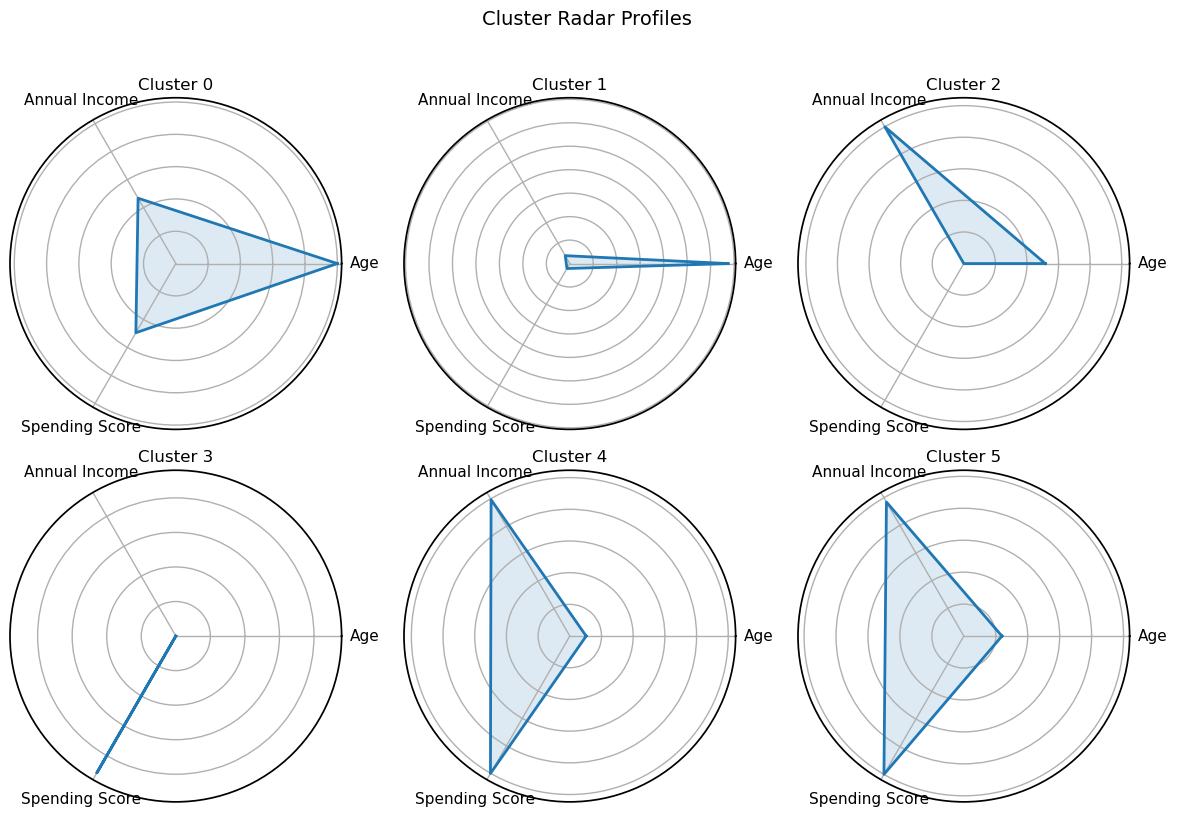

In [37]:
def radar_charts(profile_df, features=('Age', 'Annual Income', 'Spending Score'),
                title="Cluster Radar Profiles"):
    data = profile_df[list(features)].copy()
    data_norm = (data - data.min()) / (data.max() - data.min() + 1e-9)

    labels = list(features)
    num_vars = len(labels)
    angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    n_clusters = data_norm.shape[0]
    n_cols = min(3, n_clusters)
    n_rows = int(np.ceil(n_clusters / n_cols))

    fig = plt.figure(figsize=(4*n_cols, 4*n_rows))
    fig.suptitle(title, y=1.02, fontsize=14)

    for idx, (cl, row) in enumerate(data_norm.iterrows(), start=1):
        vals = row.values.tolist(); vals += vals[:1]
        ax = plt.subplot(n_rows, n_cols, idx, polar=True)
        ax.plot(angles, vals, linewidth=2)
        ax.fill(angles, vals, alpha=0.15)
        ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels)
        ax.set_yticklabels([]); ax.set_title(f"Cluster {cl}")

    plt.tight_layout(); plt.show()
radar_charts(profile[['Age','Annual Income','Spending Score']])    

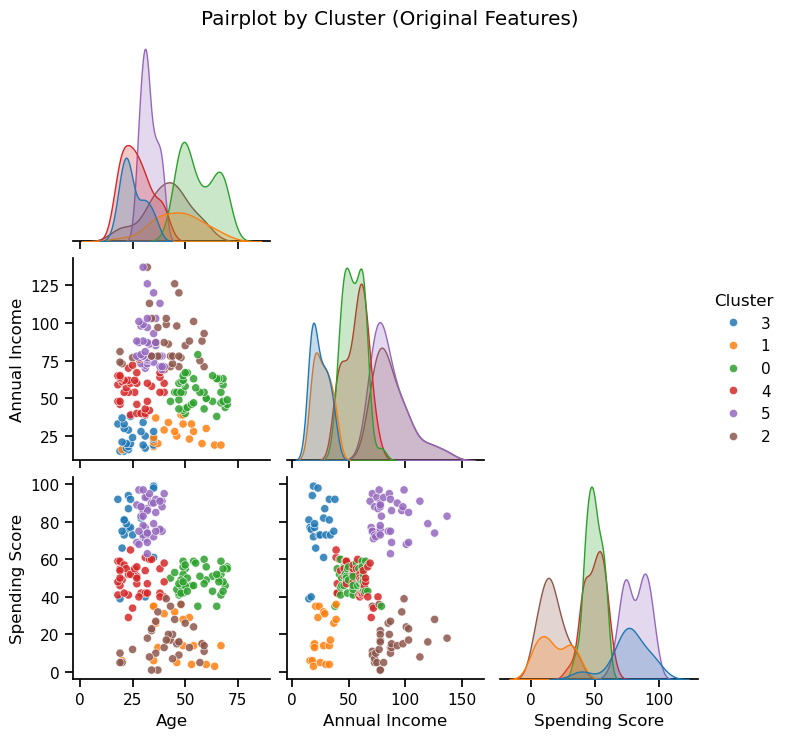

In [38]:
df_pp = df.copy()
df_pp['Cluster'] = df_pp['Cluster'].astype(str)
sns.pairplot(
    df_pp,
    vars=['Age','Annual Income','Spending Score'],
    hue='Cluster',
    height=2.4,
    corner=True,
    plot_kws=dict(s=35, alpha=0.85)
)
plt.suptitle('Pairplot by Cluster (Original Features)', y=1.02)
plt.show()

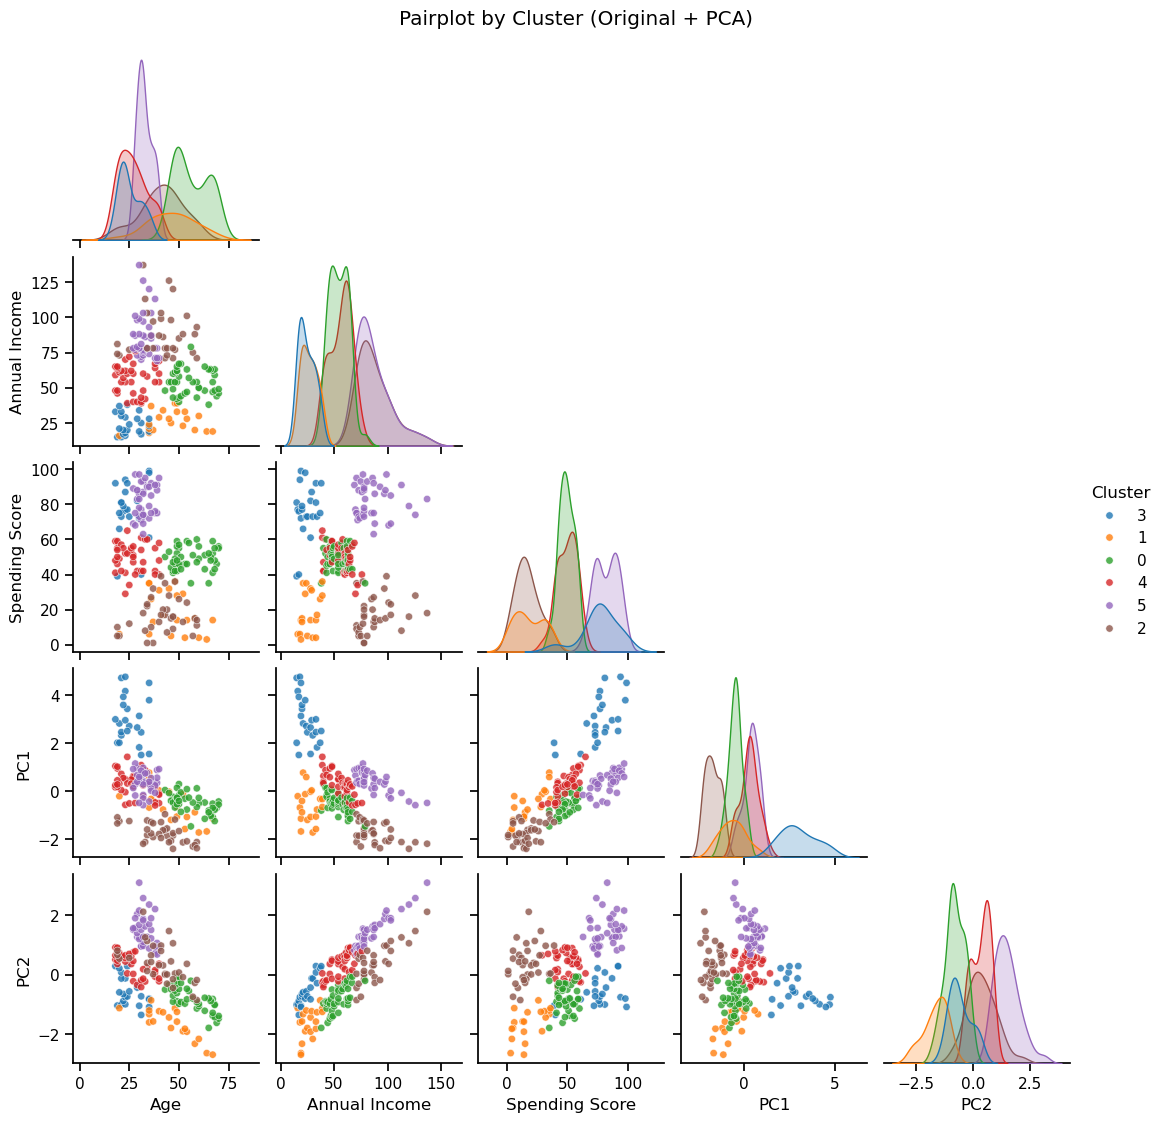

In [39]:
df_pp2 = df.copy()
df_pp2['PC1'] = X_pca[:,0]; df_pp2['PC2'] = X_pca[:,1]
df_pp2['Cluster'] = df_pp2['Cluster'].astype(str)
sns.pairplot(
    df_pp2,
    vars=['Age','Annual Income','Spending Score','PC1','PC2'],
    hue='Cluster',
    height=2.2,
    corner=True,
    plot_kws=dict(s=28, alpha=0.8)
)
plt.suptitle('Pairplot by Cluster (Original + PCA)', y=1.02)
plt.show()

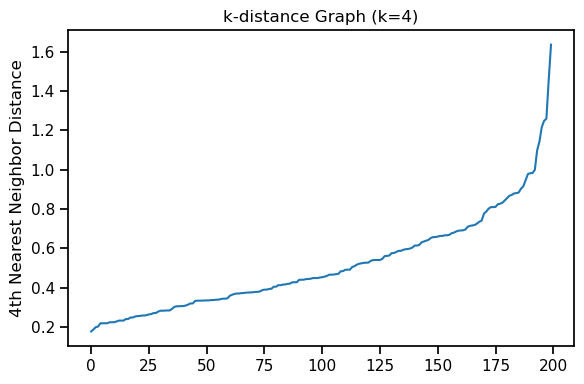

Outliers by DBSCAN (label=-1): 6


,Age,Annual Income,Spending Score
count,6.000000,6.000000,6.000000
mean,34.666667,38.166667,45.666667
std,17.397318,48.499141,42.354063
min,19.000000,15.000000,6.000000
25%,23.000000,16.750000,15.000000
50%,33.500000,19.000000,28.500000
75%,35.000000,22.000000,83.250000
max,67.000000,137.000000,99.000000


In [40]:
neighbors = NearestNeighbors(n_neighbors=4).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(6,4))
plt.plot(distances)
plt.ylabel('4th Nearest Neighbor Distance')
plt.title('k-distance Graph (k=4)')
plt.tight_layout(); plt.show()

eps = float(np.percentile(distances, 90))  # 90th percentile heuristic
dbscan = DBSCAN(eps=eps, min_samples=4)
df['DBSCAN_Label'] = dbscan.fit_predict(X_scaled)

print(f"Outliers by DBSCAN (label=-1): {int(np.sum(df['DBSCAN_Label']==-1))}")
outliers = df[df['DBSCAN_Label']==-1]
display(outliers[['Age','Annual Income','Spending Score']].describe())

Persona Matrix (based on profiles)

In [42]:
prof_num = df.groupby('Cluster').agg({
    'Age':'mean','Annual Income':'mean','Spending Score':'mean','Cluster':'count'
}).rename(columns={'Cluster':'Count'}).round(1)

personas = []
for c, row in prof_num.iterrows():
    inc, spend = row['Annual Income'], row['Spending Score']
    if inc > 70 and spend > 60:
        name, strat = "VIP Big Spenders", "Exclusive offers & VIP events"
    elif inc > 70 and spend < 40:
        name, strat = "Affluent Savers", "Upsell premium upgrades"
    elif inc < 40 and spend > 60:
        name, strat = "Budget Enthusiasts", "Student deals & discounts"
    elif inc < 40 and spend < 30:
        name, strat = "Disengaged Adults", "Reactivation campaigns"
    else:
        name, strat = "Balanced Shoppers", "Loyalty programs & bundles"
    traits = f"Age~{row['Age']:.0f} | Income~{inc:.0f} | Spend~{spend:.0f}"
    personas.append([c, name, traits, strat, int(row['Count'])])

persona_df = pd.DataFrame(personas, columns=['Cluster','Persona','Traits','Strategy','Count'])
display(persona_df)

,Cluster,Persona,Traits,Strategy,Count
0,0,Balanced Shoppers,Age~56 | Income~54 | Spend~49,Loyalty programs & bundles,45
1,1,Disengaged Adults,Age~46 | Income~27 | Spend~18,Reactivation campaigns,20
2,2,Affluent Savers,Age~41 | Income~88 | Spend~17,Upsell premium upgrades,34
3,3,Budget Enthusiasts,Age~25 | Income~24 | Spend~76,Student deals & discounts,23
4,4,Balanced Shoppers,Age~27 | Income~56 | Spend~50,Loyalty programs & bundles,39
5,5,VIP Big Spenders,Age~33 | Income~86 | Spend~82,Exclusive offers & VIP events,39


In [43]:
print("\n== Summary ==")
print(f"- Segments discovered: {best_k}")
print("- KMeans chosen for clarity; Agglo & GMM shown for comparison.")
print("- Centroids plotted on Income×Spending for intuition.")
print("- Personas auto-generated for quick marketing actions.")


== Summary ==
- Segments discovered: 6
- KMeans chosen for clarity; Agglo & GMM shown for comparison.
- Centroids plotted on Income×Spending for intuition.
- Personas auto-generated for quick marketing actions.


THANK YOU !!!!

MOHAMMED ASIF.